# PaperStreet Research

Interactive research notebook for exploring market data and strategy logic.

**Before running:** ensure TWS is open and connected on port 7497.

**Workflow:** run the Setup cell once per session. All other cells can be re-run
independently without reconnecting.

## 1. Setup
Connect to TWS once. Re-running this cell will reconnect if the session was closed.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

from research.session import Session

# Disconnect any existing session before creating a new one
try:
    session.disconnect()
except NameError:
    pass

session = Session()
print("Session ready. TWS connected:", session.is_connected)


def make_x_ticks(index, max_ticks=10):
    """
    Build integer x-axis tick positions and labels from a DatetimeIndex.

    Plots against integer positions (0, 1, 2, ...) rather than timestamps so
    matplotlib never draws connecting lines across overnight or weekend gaps.
    Tick marks are placed at session-open bars and spaced so no more than
    max_ticks labels appear regardless of how many bars are in the data.

    Parameters
    ----------
    index : DatetimeIndex
        The datetime index of the DataFrame being plotted.
    max_ticks : int
        Upper bound on the number of x-axis labels to show.

    Returns
    -------
    tick_positions : list[int]
        Integer positions where ticks should be placed.
    tick_labels : list[str]
        Formatted label for each tick position.
    """
    # A session open is any bar whose date differs from the previous bar's date
    dates = pd.Series(index.date)
    session_opens = [0] + list(dates[dates != dates.shift()].index[1:])

    # Subsample so we never show more than max_ticks labels
    step = max(1, len(session_opens) // max_ticks)
    tick_positions = session_opens[::step]
    tick_labels = [index[i].strftime("%m/%d") for i in tick_positions]

    return tick_positions, tick_labels

2026-04-02 17:41:18 INFO [session.py/disconnect.240]: Session disconnected.
2026-04-02 17:41:18 INFO [session.py/_connect.103]: Session connecting to TWS...
2026-04-02 17:41:18 INFO [ib_app.py/nextValidId.76]: nextOrderId=1
2026-04-02 17:41:18 INFO [ib_app.py/error.107]: Market data farm connection is OK (hfarm)
2026-04-02 17:41:18 INFO [ib_app.py/error.107]: Market data farm connection is OK (eufarmnj)
2026-04-02 17:41:18 INFO [ib_app.py/error.107]: Market data farm connection is OK (cashfarm)
2026-04-02 17:41:18 INFO [ib_app.py/error.107]: Market data farm connection is OK (uscrypto)
2026-04-02 17:41:18 INFO [ib_app.py/error.107]: Market data farm connection is OK (usfuture)
2026-04-02 17:41:18 INFO [ib_app.py/error.107]: Market data farm connection is OK (usopt.nj)
2026-04-02 17:41:18 INFO [ib_app.py/error.107]: Market data farm connection is OK (jfarm)
2026-04-02 17:41:18 INFO [ib_app.py/error.107]: Market data farm connection is OK (usfarm.nj)
2026-04-02 17:41:18 INFO [ib_app.py/e

Session ready. TWS connected: True


## 2. Fetch Data

Pull bars for a symbol. Adjust `SYMBOL`, `BAR_SIZE`, and `DURATION` to explore different instruments and resolutions.

**Bar size / max duration combinations (IBKR enforced):**

| BAR_SIZE   | Max DURATION |
|------------|--------------|
| `1 min`    | `1 W`        |
| `5 mins`   | `1 M`        |
| `15 mins`  | `1 M`        |
| `30 mins`  | `1 M`        |
| `1 hour`   | `1 Y`        |
| `1 day`    | `5 Y`        |

In [39]:
SYMBOL   = "SPY"
DURATION = "1 M"   # 1 W | 1 M | 3 M | 6 M | 1 Y | 2 Y | 5 Y
BAR_SIZE = "1 min" # 1 min | 5 mins | 15 mins | 30 mins | 1 hour | 1 day

df = session.market_data.get_bars(SYMBOL, duration=DURATION, bar_size=BAR_SIZE)

print(f"\n{SYMBOL} — {len(df)} bars ({DURATION})")
print(f"From : {df.index[0].date()}")
print(f"To   : {df.index[-1].date()}")
print(f"\nShape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print(f"Dtypes  :\n{df.dtypes}")
df.head()

2026-04-02 17:48:30 INFO [ibkr_client.py/get_historical_data.68]: Requesting historical data: symbol=SPY duration=1 M bar_size=1 min
2026-04-02 17:48:30 INFO [contract_handler.py/contract.22]: Contract created for SPY
2026-04-02 17:48:38 INFO [ib_app.py/historicalDataEnd.299]: Historical data received: 20260302 17:48:30 America/Chicago → 20260402 17:48:30 America/Chicago
2026-04-02 17:48:38 INFO [ibkr_client.py/get_historical_data.102]: Received 8580 bars for SPY



SPY — 8580 bars (1 M)
From : 2026-03-04
To   : 2026-04-02

Shape   : (8580, 5)
Columns : ['open', 'high', 'low', 'close', 'volume']
Dtypes  :
open      float64
high      float64
low       float64
close     float64
volume     object
dtype: object


,open,high,low,close,volume
datetime,,,,,
2026-03-04 08:30:00-06:00,681.63,683.52,681.40,682.78,668610
2026-03-04 08:31:00-06:00,682.81,683.07,682.15,682.21,355815
2026-03-04 08:32:00-06:00,682.24,682.91,682.19,682.42,263483
2026-03-04 08:33:00-06:00,682.41,682.80,682.26,682.63,230216
2026-03-04 08:34:00-06:00,682.62,682.94,682.43,682.80,352355


## 3. Price & Volume Chart
OHLC bar chart with volume subplot.

C:\Users\kylek\AppData\Local\Temp\ipykernel_29872\2271784605.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


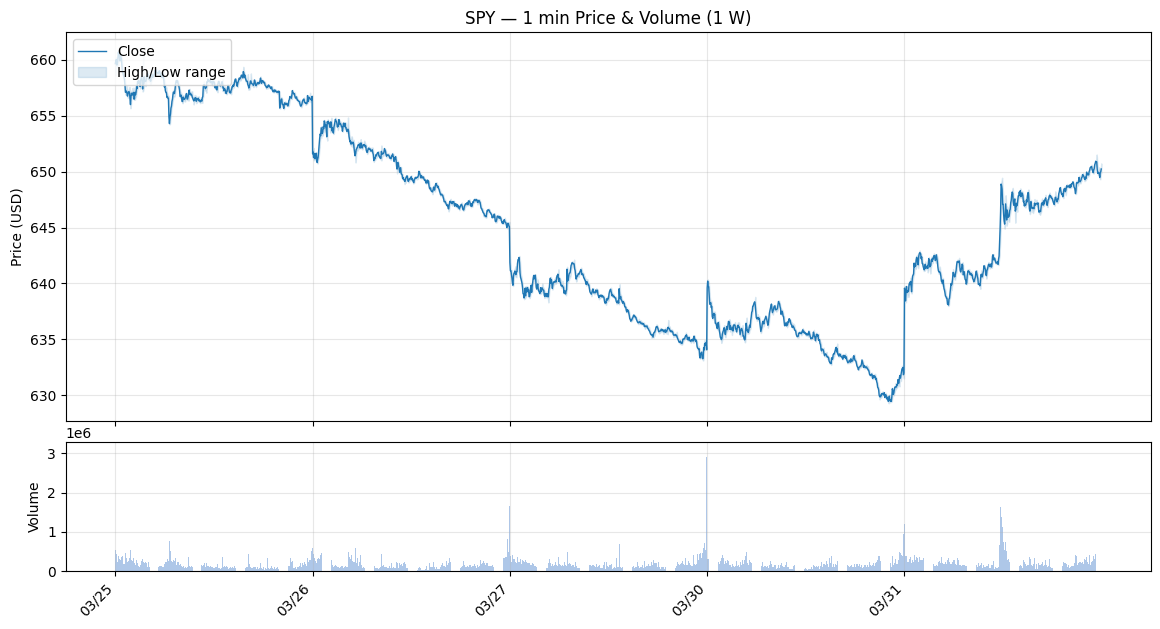

In [28]:
x = np.arange(len(df))
tick_pos, tick_labels = make_x_ticks(df.index)

fig = plt.figure(figsize=(14, 7))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)

ax_price  = fig.add_subplot(gs[0])
ax_volume = fig.add_subplot(gs[1], sharex=ax_price)

# --- Price: close line + high/low range shaded ---
ax_price.plot(x, df["close"], color="#1f77b4", linewidth=1.0, label="Close")
ax_price.fill_between(x, df["low"], df["high"], alpha=0.15, color="#1f77b4", label="High/Low range")
ax_price.set_ylabel("Price (USD)")
ax_price.set_title(f"{SYMBOL} — {BAR_SIZE} Price & Volume ({DURATION})")
ax_price.legend(loc="upper left")
ax_price.grid(True, alpha=0.3)
plt.setp(ax_price.get_xticklabels(), visible=False)

# --- Volume ---
ax_volume.bar(x, df["volume"], color="#aec7e8", width=0.8)
ax_volume.set_ylabel("Volume")
ax_volume.grid(True, alpha=0.3)
ax_volume.set_xticks(tick_pos)
ax_volume.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [41]:
# --- Feature engineering ---

# normalized deviation: deviation scaled by volatility so it's comparable across different vol regimes
df["deviation_norm"] = df["deviation"] / df["volatility"]

# SMA slope: how fast fair value is moving (rising or falling)
df["sma_slope"] = df["sma"].diff(5) / df["sma"].shift(5)

# volume ratio: current volume relative to recent average (is this bar unusually active?)
df["volume_ratio"] = df["volume"] / df["volume"].rolling(20).mean()

# --- Label: was this a profitable trade? ---
# forward_return = price 5 bars from now vs current price
df["forward_return"] = df["close"].shift(-5) / df["close"] - 1

# binary label: 1 if price went up meaningfully, 0 otherwise
df["label"] = (df["forward_return"] > 0.0005).astype(int)

# drop rows where any feature or label is NaN
# (happens at the start of the window and at the tail where forward_return can't be computed)
df_ml = df[["deviation_norm", "volatility", "sma_slope", "volume_ratio", "label"]].dropna()

print(f"ML-ready rows: {len(df_ml)}")
print(f"Label distribution:\n{df_ml['label'].value_counts()}")
df_ml.head()

KeyError: 'deviation'

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df_ml[["deviation_norm", "volatility", "sma_slope", "volume_ratio"]]
y = df_ml["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test)))

KeyError: "None of [Index(['deviation_norm', 'volatility', 'sma_slope', 'volume_ratio'], dtype='object')] are in the [columns]"

## 4. Indicator Analysis — Mean Reversion Strategy Parameters

Computes the same indicators `MeanReversionStrategy` uses internally:
- **SMA** (fair value)
- **Volatility bands** (SMA ± spread_multiplier × rolling std dev)

**Tunable parameters — adjust these and re-run to explore:**

| Parameter          | Description                                                        |
|--------------------|--------------------------------------------------------------------|
| `WINDOW`           | Lookback bars for SMA and volatility. Larger = smoother/slower.   |
| `SPREAD_MULTIPLIER`| How many std devs price must move to trigger a signal.            |
| `MAX_POSITION`     | Hard cap on shares held at once.                                  |
| `ORDER_SIZE`       | Shares per trade.                                                  |

In [30]:
# --- Strategy parameters: adjust these ---
WINDOW            = 20
SPREAD_MULTIPLIER = 1.0
MAX_POSITION      = 50
ORDER_SIZE        = 10

# --- Compute indicators (mirrors MeanReversionStrategy internals) ---
df["sma"]        = df["close"].rolling(WINDOW).mean()
df["volatility"] = df["close"].rolling(WINDOW).std()
df["upper_band"] = df["sma"] + SPREAD_MULTIPLIER * df["volatility"]
df["lower_band"] = df["sma"] - SPREAD_MULTIPLIER * df["volatility"]
df["deviation"]  = df["close"] - df["sma"]

print(f"Window: {WINDOW} bars | Spread multiplier: {SPREAD_MULTIPLIER} | Max position: {MAX_POSITION} | Order size: {ORDER_SIZE}")
print(f"\nCurrent deviation from fair value : {df['deviation'].iloc[-1]:.4f}")
print(f"Current threshold (±)             : {(SPREAD_MULTIPLIER * df['volatility'].iloc[-1]):.4f}")
df[["close", "sma", "upper_band", "lower_band", "deviation"]].tail(10)

Window: 20 bars | Spread multiplier: 1.0 | Max position: 50 | Order size: 10

Current deviation from fair value : 0.0175
Current threshold (±)             : 0.4043


,close,sma,upper_band,lower_band,deviation
datetime,,,,,
2026-03-31 14:50:00-05:00,650.88,650.2685,650.664829,649.872171,0.6115
2026-03-31 14:51:00-05:00,650.20,650.2930,650.667533,649.918467,-0.0930
2026-03-31 14:52:00-05:00,649.85,650.2990,650.664900,649.933100,-0.4490
2026-03-31 14:53:00-05:00,649.94,650.3050,650.663542,649.946458,-0.3650
2026-03-31 14:54:00-05:00,649.90,650.3145,650.658677,649.970323,-0.4145
2026-03-31 14:55:00-05:00,649.84,650.3060,650.660050,649.951950,-0.4660
2026-03-31 14:56:00-05:00,649.48,650.2740,650.671947,649.876053,-0.7940
2026-03-31 14:57:00-05:00,649.92,650.2530,650.658295,649.847705,-0.3330
2026-03-31 14:58:00-05:00,650.00,650.2330,650.640523,649.825477,-0.2330


## 5. Signal Overlay
Visualize where the mean reversion strategy would have generated BUY and SELL signals on the fetched data.

Window=20 | Multiplier=1.0 | Max position=50 | Order size=10
BUY signals : 160
SELL signals: 155


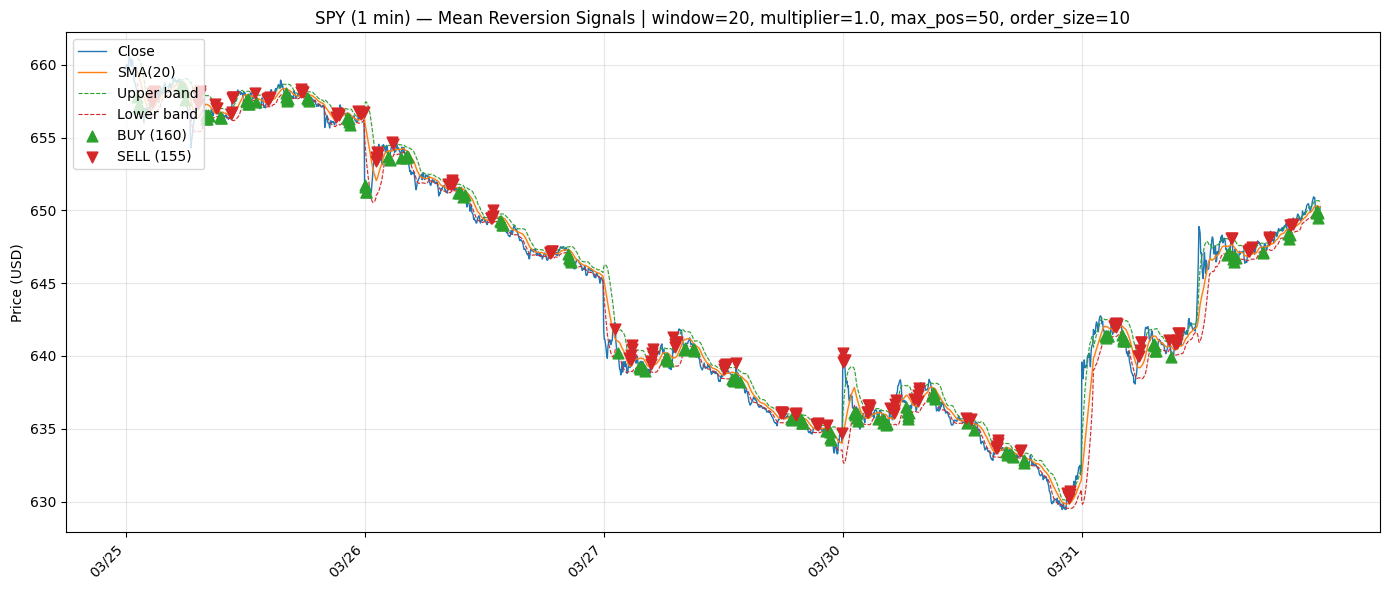

In [31]:
# Derive signals — mirrors on_bar logic in MeanReversionStrategy exactly
df["signal"] = None
position = 0

for i in range(len(df)):
    row = df.iloc[i]
    if pd.isna(row["sma"]):
        continue

    deviation = row["deviation"]
    threshold = SPREAD_MULTIPLIER * row["volatility"]

    if deviation < -threshold and position < MAX_POSITION:
        df.at[df.index[i], "signal"] = "BUY"
        position += ORDER_SIZE
    elif deviation > threshold and position > 0:
        df.at[df.index[i], "signal"] = "SELL"
        position = max(0, position - ORDER_SIZE)

buy_signals  = df[df["signal"] == "BUY"]
sell_signals = df[df["signal"] == "SELL"]

print(f"Window={WINDOW} | Multiplier={SPREAD_MULTIPLIER} | Max position={MAX_POSITION} | Order size={ORDER_SIZE}")
print(f"BUY signals : {len(buy_signals)}")
print(f"SELL signals: {len(sell_signals)}")

# Integer positions for gap-free plotting
x = np.arange(len(df))
buy_x  = [df.index.get_loc(i) for i in buy_signals.index]
sell_x = [df.index.get_loc(i) for i in sell_signals.index]
tick_pos, tick_labels = make_x_ticks(df.index)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x, df["close"],      color="#1f77b4", linewidth=1.0, label="Close",               zorder=2)
ax.plot(x, df["sma"],        color="#ff7f0e", linewidth=1.0, label=f"SMA({WINDOW})",      zorder=2)
ax.plot(x, df["upper_band"], color="#2ca02c", linewidth=0.8, linestyle="--", label="Upper band", zorder=2)
ax.plot(x, df["lower_band"], color="#d62728", linewidth=0.8, linestyle="--", label="Lower band", zorder=2)
ax.fill_between(x, df["lower_band"], df["upper_band"], alpha=0.06, color="gray")

ax.scatter(buy_x,  buy_signals["close"],  marker="^", color="#2ca02c", s=60, zorder=3, label=f"BUY ({len(buy_signals)})")
ax.scatter(sell_x, sell_signals["close"], marker="v", color="#d62728", s=60, zorder=3, label=f"SELL ({len(sell_signals)})")

ax.set_title(f"{SYMBOL} ({BAR_SIZE}) — Mean Reversion Signals | window={WINDOW}, multiplier={SPREAD_MULTIPLIER}, max_pos={MAX_POSITION}, order_size={ORDER_SIZE}")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Multi-Symbol Comparison
Compare relative performance and correlation across a basket of symbols.
Adjust `SYMBOLS` and `DURATION` freely.

In [6]:
SYMBOLS  = ["SPY", "QQQ", "IWM"]
DURATION = "3 M"

closes = session.market_data.get_close_prices(SYMBOLS, duration=DURATION)

print(f"Fetched {len(closes)} aligned dates across {SYMBOLS}")
closes.tail()

2026-03-31 17:22:28 INFO [ibkr_client.py/get_historical_data.68]: Requesting historical data: symbol=SPY duration=3 M bar_size=1 day
2026-03-31 17:22:28 INFO [contract_handler.py/contract.22]: Contract created for SPY
2026-03-31 17:22:29 INFO [ib_app.py/historicalDataEnd.299]: Historical data received: 20251231 17:22:28 America/Chicago → 20260331 17:22:28 America/Chicago
2026-03-31 17:22:29 INFO [ibkr_client.py/get_historical_data.102]: Received 61 bars for SPY
2026-03-31 17:22:29 INFO [market_data_service.py/get_daily_bars_multi.142]: Fetched SPY (1/3)
2026-03-31 17:22:29 INFO [ibkr_client.py/get_historical_data.68]: Requesting historical data: symbol=QQQ duration=3 M bar_size=1 day
2026-03-31 17:22:29 INFO [contract_handler.py/contract.22]: Contract created for QQQ
2026-03-31 17:22:29 INFO [ib_app.py/historicalDataEnd.299]: Historical data received: 20251231 17:22:29 America/Chicago → 20260331 17:22:29 America/Chicago
2026-03-31 17:22:29 INFO [ibkr_client.py/get_historical_data.102]:

Fetched 61 aligned dates across ['SPY', 'QQQ', 'IWM']


,SPY,QQQ,IWM
datetime,,,
2026-03-25,656.82,587.82,251.82
2026-03-26,645.09,573.79,247.44
2026-03-27,634.09,562.58,243.10
2026-03-30,631.97,558.28,239.61
2026-03-31,650.34,577.18,248.00


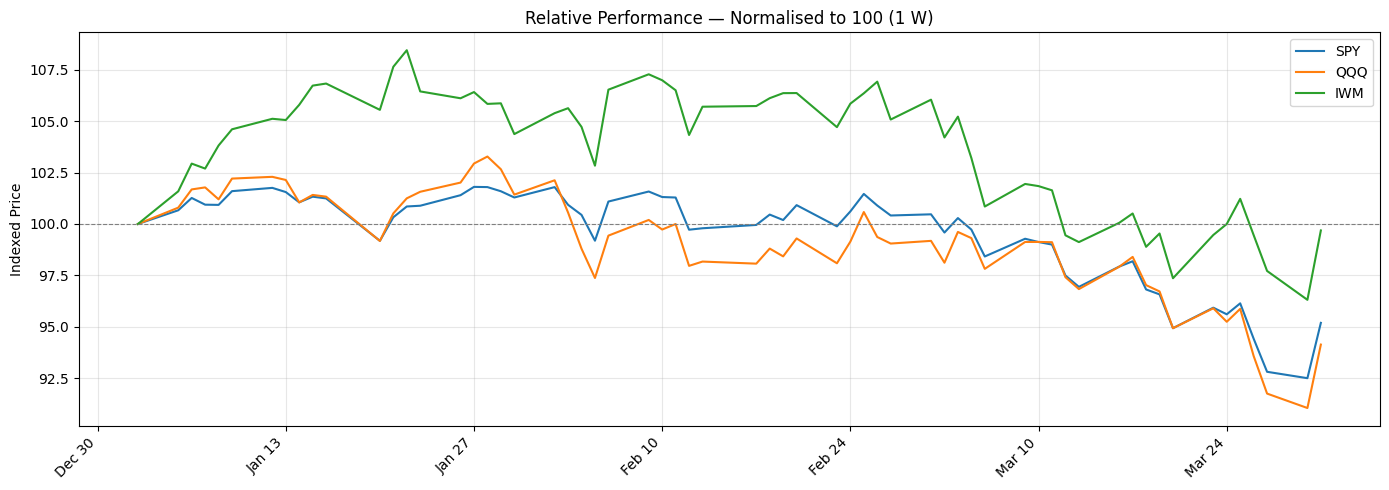

In [32]:
# Normalise to 100 at the start so all series are comparable on the same axis
normalised = (closes / closes.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 5))

for symbol in SYMBOLS:
    ax.plot(normalised.index, normalised[symbol], linewidth=1.5, label=symbol)

ax.axhline(100, color="gray", linewidth=0.8, linestyle="--")
ax.set_title(f"Relative Performance — Normalised to 100 ({DURATION})")
ax.set_ylabel("Indexed Price")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Daily return correlation matrix:
        SPY     QQQ     IWM
SPY  1.0000  0.9616  0.8536
QQQ  0.9616  1.0000  0.7915
IWM  0.8536  0.7915  1.0000


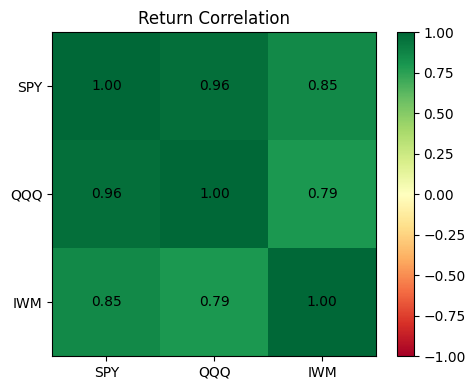

In [8]:
# Correlation matrix of daily returns
returns = closes.pct_change().dropna()
corr    = returns.corr()

print("Daily return correlation matrix:")
print(corr.round(4))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdYlGn")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(SYMBOLS)))
ax.set_yticks(range(len(SYMBOLS)))
ax.set_xticklabels(SYMBOLS)
ax.set_yticklabels(SYMBOLS)

for i in range(len(SYMBOLS)):
    for j in range(len(SYMBOLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)

ax.set_title("Return Correlation")
plt.tight_layout()
plt.show()

## 7. Teardown
Disconnect from TWS when you are done. Safe to skip if you plan to keep the session open.

In [9]:
session.disconnect()
print("Disconnected. Session active:", session.is_connected)

2026-03-31 17:22:49 INFO [session.py/disconnect.236]: Session disconnecting from TWS...
2026-03-31 17:22:49 INFO [session.py/disconnect.240]: Session disconnected.


Disconnected. Session active: False
